In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('/kaggle/input/titanic/train.csv')
x_test=pd.read_csv('/kaggle/input/titanic/test.csv')
y_tested=pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
x_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
y_tested.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [6]:
data.shape

(891, 12)

In [7]:
y_tested.shape

(418, 2)

In [8]:
x_test.shape

(418, 11)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
data['Age'].isnull().sum()

177

In [11]:
data['Age'].fillna(data['Age'].median(),inplace=True)

In [12]:
data['Age'].isna().sum()

0

In [13]:
data['Embarked'].isna().sum()

2

In [14]:
data['Embarked'].mode()

0    S
dtype: object

In [15]:
data['Embarked'].fillna(data['Embarked'].mode()[0],inplace=True)

In [16]:
data['Embarked'].isnull().sum()

0

In [17]:
data.drop('Cabin',axis=1,inplace=True)

In [18]:
data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

<AxesSubplot:>

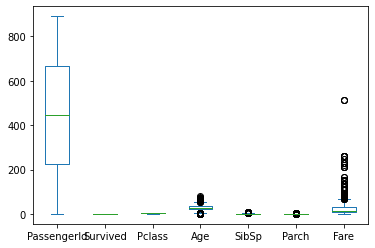

In [19]:
data.plot(kind='box')

{'whiskers': [<matplotlib.lines.Line2D at 0x7f8a4078f4d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f8a4078fb50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f8a4078f110>],
 'medians': [<matplotlib.lines.Line2D at 0x7f8a4079b250>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f8a4079b590>],
 'means': []}

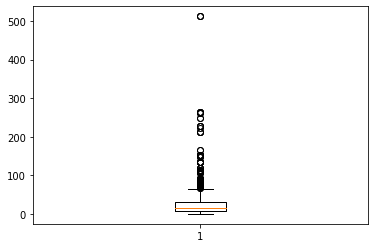

In [20]:
box=plt.boxplot(data['Fare'])
box

In [21]:
from scipy.stats.mstats import winsorize

In [22]:
data['Fare']=winsorize(data['Fare'],(0.05,0.05),inplace=True)

<AxesSubplot:>

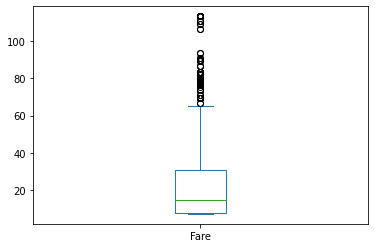

In [23]:
data['Fare'].plot(kind='box')

In [24]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [25]:
data.drop(columns=['Ticket','Name'],axis=1,inplace=True)

In [26]:
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [27]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [28]:
x_test['Age'].fillna(x_test['Age'].median(),inplace=True)

In [29]:
x_test['Fare'].fillna(x_test['Fare'].mean(),inplace=True)

In [30]:
x_test.drop('Cabin',axis=True,inplace=True)

In [31]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


In [32]:
x_test.drop(columns=['Name','Ticket'],inplace=True)

In [33]:
x_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,male,34.5,0,0,7.8292,Q
1,893,3,female,47.0,1,0,7.0000,S
2,894,2,male,62.0,0,0,9.6875,Q
3,895,3,male,27.0,0,0,8.6625,S
4,896,3,female,22.0,1,1,12.2875,S


In [34]:
x_test=pd.get_dummies(x_test)
x_test.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,34.5,0,0,7.8292,0,1,0,1,0
1,893,3,47.0,1,0,7.0000,1,0,0,0,1
2,894,2,62.0,0,0,9.6875,0,1,0,1,0
3,895,3,27.0,0,0,8.6625,0,1,0,0,1
4,896,3,22.0,1,1,12.2875,1,0,0,0,1


In [35]:
x_test.isna().sum()

PassengerId    0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Sex_female     0
Sex_male       0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [36]:
y_test=y_tested.drop('PassengerId',axis=1)

In [37]:
x_train=data.drop('Survived',axis=1)
y_train=data.iloc[:,[1]]
x_test=x_test
y_test=y_test

In [38]:
y_train.value_counts()

Survived
0           549
1           342
dtype: int64

In [39]:
from imblearn.over_sampling import SMOTE

In [40]:
x_train=pd.get_dummies(x_train)

In [41]:
sm=SMOTE()
x_train,y_train=sm.fit_resample(x_train,y_train)

In [42]:
y_train.value_counts()

Survived
0           549
1           549
dtype: int64

In [43]:
y_test.value_counts()

Survived
0           266
1           152
dtype: int64

In [44]:
x_train.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,0,1,0,0,1
1,2,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,3,26.0,0,0,7.9250,1,0,0,0,1
3,4,1,35.0,1,0,53.1000,1,0,0,0,1
4,5,3,35.0,0,0,8.0500,0,1,0,0,1


# Using Logistic Regression 

In [45]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [46]:
scaler=MinMaxScaler()
x=scaler.fit_transform(x_train)

In [47]:
l_g=LogisticRegression(random_state=42,n_jobs=-1)
params={'penalty':['l1', 'l2', 'elasticnet'],'max_iter':[100,200,300]}
model1=GridSearchCV(l_g,param_grid=params,cv=10)
model1.fit(x_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example usin

GridSearchCV(cv=10, estimator=LogisticRegression(n_jobs=-1, random_state=42),
             param_grid={'max_iter': [100, 200, 300],
                         'penalty': ['l1', 'l2', 'elasticnet']})

In [48]:
model1.best_params_

{'max_iter': 300, 'penalty': 'l2'}

In [49]:
model1.best_score_

0.8097831526271893

In [50]:
model1.score(x_train,y_train)

0.8178506375227687

In [51]:
y_pred=model1.predict(x_test)

In [52]:
result_1=model1.score(x_test,y_test)

In [53]:
from sklearn.metrics import classification_report

In [54]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       240
           1       0.97      0.83      0.89       178

    accuracy                           0.91       418
   macro avg       0.93      0.90      0.91       418
weighted avg       0.92      0.91      0.91       418



# Using Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [56]:
d_t=DecisionTreeClassifier(random_state=42)
params={'max_depth':range(1,8)}
model2=GridSearchCV(d_t,param_grid=params,cv=10)
model2.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': range(1, 8)})

In [57]:
model2.best_params_

{'max_depth': 1}

In [58]:
model2.best_score_

0.8079566305254378

In [59]:
model2.score(x_train,y_train)

0.807832422586521

In [60]:
y_pred=model2.predict(x_test)

In [61]:
result_2=model2.score(x_test,y_test)

In [62]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       266
           1       1.00      1.00      1.00       152

    accuracy                           1.00       418
   macro avg       1.00      1.00      1.00       418
weighted avg       1.00      1.00      1.00       418



# Using Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
r_f_c=RandomForestClassifier(random_state=42,bootstrap=True,n_jobs=-1)
params={'n_estimators':[100,200,300],'max_depth':range(1,8)}
g_v=GridSearchCV(r_f_c,params,cv=10)
model3=g_v.fit(x_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 

In [65]:
model3.best_params_

{'max_depth': 3, 'n_estimators': 100}

In [66]:
model3.best_score_

0.8151876563803169

In [67]:
result_3=model3.score(x_test,y_test)

In [68]:
y_pred=model3.predict(x_test)

In [69]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       266
           1       0.98      0.98      0.98       152

    accuracy                           0.99       418
   macro avg       0.98      0.98      0.98       418
weighted avg       0.99      0.99      0.99       418



# Using Bagging

In [70]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [71]:
base=DecisionTreeClassifier(random_state=42)
bag=BaggingClassifier(base_estimator=base,random_state=42,bootstrap=True)
kf=KFold(n_splits=20,shuffle=True)
params={'n_estimators':range(1,40)}
g_v=GridSearchCV(bag,param_grid=params,cv=kf,n_jobs=-1)
model4=g_v.fit(x_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [72]:
model4.best_params_

{'n_estimators': 34}

In [73]:
model4.best_score_

0.8461784511784509

In [74]:
result_4=model4.score(x_test,y_test)

In [75]:
y_pred=model4.predict(x_test)

In [76]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       285
           1       0.70      0.80      0.74       133

    accuracy                           0.83       418
   macro avg       0.80      0.82      0.81       418
weighted avg       0.83      0.83      0.83       418



# Using Boosting

In [77]:
from sklearn.ensemble import AdaBoostClassifier

In [78]:
base=DecisionTreeClassifier(random_state=42)
ada=AdaBoostClassifier(base_estimator=base,random_state=42)
params={'n_estimators':range(5,100)}
k_f=KFold(n_splits=10,shuffle=True)
g_v=GridSearchCV(ada,param_grid=params,cv=k_f,n_jobs=-1)
model5=g_v.fit(x_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_bagging.py:719: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_bagging.py:719: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_bagging.py:719: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_bagging.py:719: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example 

In [79]:
model5.best_params_

{'n_estimators': 5}

In [80]:
model5.best_score_

0.7923769808173479

In [81]:
result_5=model5.score(x_test,y_test)

In [82]:
y_pred=model5.predict(x_test)

In [83]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       267
           1       0.72      0.72      0.72       151

    accuracy                           0.80       418
   macro avg       0.78      0.78      0.78       418
weighted avg       0.80      0.80      0.80       418



# Checking All Models Test Acccuracy

In [84]:
data2=[['Logistic regression',result_1],['Decision Tree',result_2],['Random forest',result_3],['Bagging',result_4],['Boosting_Ada',result_5]]

In [85]:
models=pd.DataFrame(data2,columns=['Models','Accuracy'])

In [86]:
models

,Models,Accuracy
0,Logistic regression,0.913876
1,Decision Tree,1.000000
2,Random forest,0.985646
3,Bagging,0.825359
4,Boosting_Ada,0.796651


In [87]:
prediction=model3.predict(x_test)

In [88]:
model3.score(x_test,y_test)

0.9856459330143541

In [89]:
x_test.shape

(418, 11)

In [90]:
final=pd.DataFrame(prediction,columns=['Prediction'])

In [91]:
y_test_pass=y_tested.drop('Survived',axis=1)

In [92]:
final.insert(0,'PassengerId',y_test_pass)

In [93]:
final

,PassengerId,Prediction
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [94]:
final.to_csv('Kaggel_final.csv')